In [5]:
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from pathlib import Path
from scipy import stats
from scipy.stats import kruskal, mannwhitneyu

# Editable text in Adobe Illustrator (Type 42 = TrueType embedded, not outlines)
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype']  = 42
matplotlib.rcParams['font.size']    = 10

# Locate repo root from wherever Jupyter was launched
_cwd  = Path(os.getcwd()).resolve()
ROOT  = _cwd
for _ in range(6):
    if (ROOT / 'models').is_dir() and (ROOT / 'data').is_dir():
        break
    ROOT = ROOT.parent
os.chdir(ROOT)

NB_DIR     = ROOT / 'analysis' / 'feature_importance'
DATA_DIR   = NB_DIR / 'data'
FIGURE_DIR = NB_DIR / 'figures'
OCCLUSION_DIR = ROOT / 'analysis' / 'feature_importance' / 'data'
FIGURE_DIR.mkdir(exist_ok=True)

MMS_CSV = DATA_DIR / 'MHCflurry_training.csv'

POS_LABELS = ['P1', 'P2', 'P3', 'P4', 'P\u03a9-3', 'P\u03a9-2', 'P\u03a9-1', 'P\u03a9']
N_POS      = 8
CLUSTER_COLORS = {0: '#45566B', 1: '#EDC264', 2: '#F28482', 3: '#84A59D'}

MMS_LENGTH_COL = {
    8:  {'P1': '0',  'P2': '1',  'P3': '2',  'P4': '3',
         'P\u03a9-3': '4',  'P\u03a9-2': '5',  'P\u03a9-1': '6',  'P\u03a9': '7'},
    9:  {'P1': '8',  'P2': '9',  'P3': '10', 'P4': '11',
         'P\u03a9-3': '13', 'P\u03a9-2': '14', 'P\u03a9-1': '15', 'P\u03a9': '16'},
    10: {'P1': '17', 'P2': '18', 'P3': '19', 'P4': '20',
         'P\u03a9-3': '23', 'P\u03a9-2': '24', 'P\u03a9-1': '25', 'P\u03a9': '26'},
    11: {'P1': '27', 'P2': '28', 'P3': '29', 'P4': '30',
         'P\u03a9-3': '34', 'P\u03a9-2': '35', 'P\u03a9-1': '36', 'P\u03a9': '37'},
}


In [6]:
# ── Load data ─────────────────────────────────────────────────────────────────
df = pd.read_csv(OCCLUSION_DIR / 'per_sample_delta.csv')
df['pos_label'] = pd.Categorical(df['pos_label'], categories=POS_LABELS, ordered=True)

mms_tr = pd.read_csv(MMS_CSV, index_col=0)  # MHCflurry_training.csv
mms_tr.columns = mms_tr.columns.astype(str)
mms_tr.index.name = 'MHC'

# ── Per-HLA mean Δscore per canonical position ────────────────────────────────
valid = (df.groupby(['MHC', 'cluster', 'pos_label'], observed=True)
           .agg(mean_delta=('delta', 'mean'), n_samples=('sample_idx', 'nunique'))
           .reset_index())

# ── Length-weighted MMS conservation ──────────────────────────────────────────
hla_len_n = (df.groupby(['MHC', 'pep_len'], observed=True)['sample_idx']
               .nunique().rename('n_len').reset_index())
mms_rows = []
for plen, col_map in MMS_LENGTH_COL.items():
    for pos, col in col_map.items():
        tmp = mms_tr[[col]].copy(); tmp.columns = ['mms_val']
        tmp = tmp.reset_index(); tmp['pep_len'] = plen; tmp['pos_label'] = pos
        mms_rows.append(tmp)
mms_long = pd.concat(mms_rows, ignore_index=True)
merged   = hla_len_n.merge(mms_long, on=['MHC', 'pep_len'])
merged['wt_mms'] = merged['n_len'] * merged['mms_val']
g = merged.groupby(['MHC', 'pos_label'], observed=True)
weighted_mms = (g['wt_mms'].sum() / g['n_len'].sum()).rename('mms_conservation').reset_index()
valid = valid.merge(weighted_mms, on=['MHC', 'pos_label'], how='left').dropna(subset=['mms_conservation'])

# ── Cluster-level summary: mean Δscore ± t-based 95% CI ──────────────────────────
cluster_pos = (valid.groupby(['cluster', 'pos_label'], observed=True)
               .agg(mean_score=('mean_delta', 'mean'),
                    sem_score  =('mean_delta', lambda x: x.std(ddof=1) / np.sqrt(len(x))),
                    mean_mms   =('mms_conservation', 'mean'))
               .reset_index())
from scipy.stats import t as t_dist
n_hlas = valid.groupby('cluster', observed=True)['MHC'].nunique().rename('n_hla')
cluster_pos = cluster_pos.merge(n_hlas.reset_index(), on='cluster')
cluster_pos['t_crit'] = cluster_pos['n_hla'].apply(lambda n: t_dist.ppf(0.975, df=n - 1))
cluster_pos['ci95']   = cluster_pos['t_crit'] * cluster_pos['sem_score']

# ── Spearman ρ (Δscore vs MMS conservation) ────────────────────────────────────
rho_stats = {}
for cid in range(4):
    sub = valid[valid['cluster'] == cid]
    r, p = stats.spearmanr(sub['mean_delta'], sub['mms_conservation'])
    rho_stats[f'C{cid+1}'] = dict(rho=r, p=p, n=len(sub), color=CLUSTER_COLORS[cid])
r_all, p_all = stats.spearmanr(valid['mean_delta'], valid['mms_conservation'])
rho_stats['Overall'] = dict(rho=r_all, p=p_all, n=len(valid), color='#6B6B6B')

# ── Kruskal-Wallis per position (Δscore) ──────────────────────────────────────
def bh_fdr(pvals):
    pvals = np.asarray(pvals, dtype=float); n = len(pvals)
    order = np.argsort(pvals)
    adj   = np.minimum(1.0, pvals[order] * n / np.arange(1, n + 1))
    adj   = np.minimum.accumulate(adj[::-1])[::-1]
    result = np.empty_like(adj); result[order] = adj; return result

kw_rows = []
for pos in POS_LABELS:
    groups = [valid[(valid['cluster'] == cid) & (valid['pos_label'] == pos)]['mean_delta'].values
              for cid in range(4)]
    H, p = kruskal(*[g for g in groups if len(g) > 0])
    kw_rows.append({'pos_label': pos, 'H': H, 'p_kw': p})
kw_df = pd.DataFrame(kw_rows)
kw_df['p_adj'] = bh_fdr(kw_df['p_kw'].values)

# ── Summary ────────────────────────────────────────────────────────────────────
print(f'Samples: {len(df):,}  |  {df["Peptide"].nunique():,} peptides  |  {df["MHC"].nunique()} HLAs')
print(f'Clusters: { {f"C{c+1}": int((valid["cluster"]==c).sum()//8) for c in range(4)} }')
print()
print('Spearman ρ (mean_delta vs MMS score):')
for k, v in rho_stats.items():
    stars = '**' if v['p'] < 0.01 else ('*' if v['p'] < 0.05 else 'n.s.')
    print(f'  {k:12s}: ρ={v["rho"]:+.3f}  p={v["p"]:.2e}  {stars}')
print()
print('Kruskal-Wallis per position (Δscore, BH-FDR):')
for _, row in kw_df.iterrows():
    stars = '**' if row['p_adj'] < 0.01 else ('*' if row['p_adj'] < 0.05 else 'n.s.')
    print(f'  {row["pos_label"]:8s}: H={row["H"]:.2f}  p_raw={row["p_kw"]:.3f}  p_adj={row["p_adj"]:.3f}  {stars}')


Samples: 79,504  |  8,804 peptides  |  65 HLAs
Clusters: {'C1': 24, 'C2': 23, 'C3': 13, 'C4': 5}

Spearman ρ (mean_delta vs MMS score):
  C1          : ρ=-0.219  p=2.25e-03  **
  C2          : ρ=-0.307  p=2.27e-05  **
  C3          : ρ=-0.490  p=1.31e-07  **
  C4          : ρ=-0.433  p=5.26e-03  **
  Overall     : ρ=-0.225  p=2.11e-07  **

Kruskal-Wallis per position (Δscore, BH-FDR):
  P1      : H=7.18  p_raw=0.066  p_adj=0.066  n.s.
  P2      : H=19.43  p_raw=0.000  p_adj=0.001  **
  P3      : H=13.28  p_raw=0.004  p_adj=0.006  **
  P4      : H=11.48  p_raw=0.009  p_adj=0.011  *
  PΩ-3    : H=13.24  p_raw=0.004  p_adj=0.006  **
  PΩ-2    : H=14.90  p_raw=0.002  p_adj=0.004  **
  PΩ-1    : H=23.74  p_raw=0.000  p_adj=0.000  **
  PΩ      : H=31.75  p_raw=0.000  p_adj=0.000  **


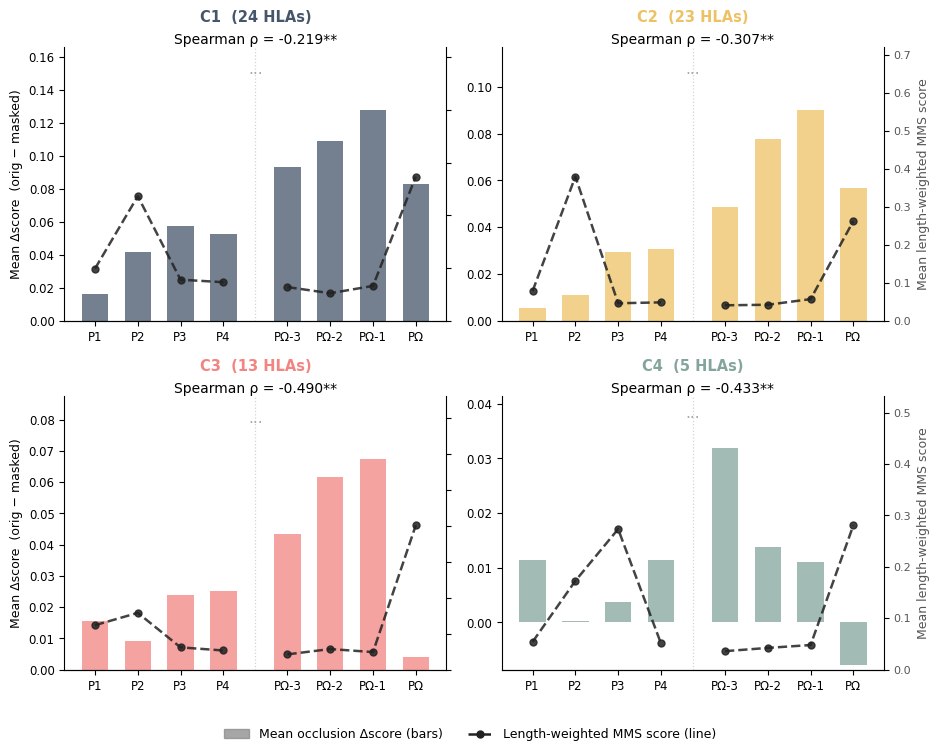

Saved fig_barline.pdf/.png


In [12]:
# ── Figure 1: Δscore bar + MMS line, per cluster (2×2) ──────────────────────
fig, axes = plt.subplots(2, 2, figsize=(9.5, 7.5))

# Extra 0.5-unit gap between P4 (idx 3) and PΩ-3 (idx 4)
x = np.array([0, 1, 2, 3, 4.5, 5.5, 6.5, 7.5])
GAP_X = 3.75  # midpoint of gap

for ax, cid in zip(axes.flat, range(4)):
    sub   = cluster_pos[cluster_pos['cluster'] == cid].set_index('pos_label').reindex(POS_LABELS)
    color = CLUSTER_COLORS[cid]
    n_hla = valid[valid['cluster'] == cid]['MHC'].nunique()
    rv    = rho_stats[f'C{cid+1}']
    stars = '**' if rv['p'] < 0.01 else ('*' if rv['p'] < 0.05 else '')

    # Bars
    ax.bar(x, sub['mean_score'],
           color=color, alpha=0.75, edgecolor='none', width=0.62, zorder=2)

    ymax = max(sub['mean_score'].max() * 1.3, 0.01)
    ymin = min(sub['mean_score'].min() * 1.1, 0)
    ax.set_ylim(ymin, ymax)
    ax.set_xticks(x)
    ax.set_xticklabels(POS_LABELS, fontsize=9)

    # Cluster title (colored, bold) + ρ subtitle (black, normal, smaller)
    ax.set_title(f'C{cid+1}  ({n_hla} HLAs)',
                 fontsize=10.5, color=color, fontweight='bold', pad=18)
    ax.text(0.5, 1.0, f'Spearman \u03c1 = {rv["rho"]:+.3f}{stars}',
            transform=ax.transAxes, ha='center', va='bottom',
            fontsize=10, color='black', fontweight='normal')

    ax.spines[['top', 'right']].set_visible(False)
    ax.tick_params(axis='both', labelsize=8.5)
    if cid in (0, 2):
        ax.set_ylabel('Mean \u0394score  (orig \u2212 masked)', fontsize=9)

    # Gap marker
    ax.axvline(GAP_X, color='#cccccc', lw=0.9, ls=':', zorder=5, alpha=0.85)
    ax.text(GAP_X, ymax * 0.90, '\u00b7\u00b7\u00b7', ha='center', va='center',
            fontsize=11, color='#aaaaaa', zorder=6)

    # MMS line — two segments, broken at gap
    mms_vals = sub['mean_mms'].values
    ax2 = ax.twinx()
    ax2.plot(x[:4], mms_vals[:4], color='#222222', marker='o', markersize=5,
             linewidth=1.8, linestyle='--', zorder=3, alpha=0.85)
    ax2.plot(x[4:], mms_vals[4:], color='#222222', marker='o', markersize=5,
             linewidth=1.8, linestyle='--', zorder=3, alpha=0.85)
    ax2.set_ylim(0, mms_vals.max() * 1.9)
    ax2.spines[['top', 'left']].set_visible(False)
    ax2.tick_params(axis='y', labelsize=8, labelcolor='#555')
    if cid in (1, 3):
        ax2.set_ylabel('Mean length-weighted MMS score',
                       fontsize=9, color='#555', labelpad=4)
    else:
        ax2.set_yticklabels([])

legend_elements = [
    Patch(color='#888', alpha=0.75, label='Mean occlusion \u0394score (bars)'),
    Line2D([0], [0], color='#222222', linewidth=1.8, linestyle='--',
           marker='o', markersize=5, label='Length-weighted MMS score (line)'),
]
fig.legend(handles=legend_elements, loc='lower center', ncol=2, fontsize=9,
           bbox_to_anchor=(0.5, -0.01), frameon=False)
#fig.suptitle('Canonical-Position Occlusion \u0394score and MMS Score per Cluster',
#             fontsize=11, y=1.01, fontweight='bold')
plt.tight_layout(rect=[0, 0.05, 1, 1])

for ext in ('pdf', 'png'):
    fig.savefig(FIGURE_DIR / f'fig_barline.{ext}', dpi=150, bbox_inches='tight')
plt.show()
print('Saved fig_barline.pdf/.png')


HLAs in PERMANOVA/PCoA: 65
cluster
0    24
1    23
2    13
3     5
Name: count, dtype: int64
pseudo-F = 6.671  R² = 0.247  p = 9.999e-05  **


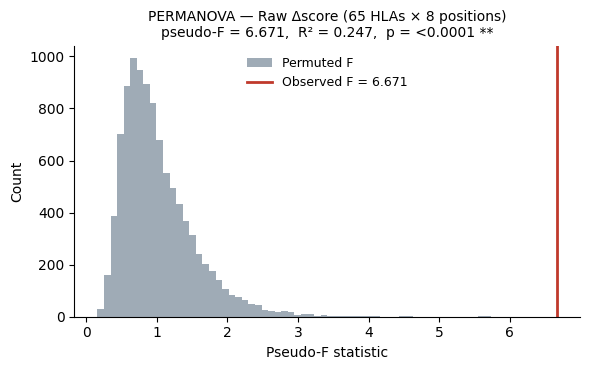

Saved fig_permanova.pdf/.png


In [8]:
# ── PERMANOVA: cluster effect on 8D Δscore profile (distance-matrix-based) ──
from scipy.spatial.distance import pdist, squareform

# Per-HLA profile matrix (retains cluster label)
profile_df = (
    valid.pivot_table(index=['MHC', 'cluster'], columns='pos_label',
                       values='mean_delta', aggfunc='mean')
    .reset_index()
)
profile_df = profile_df.dropna(subset=POS_LABELS).copy()
X          = profile_df[POS_LABELS].to_numpy(dtype=float)
hla_labels = profile_df['cluster'].to_numpy()
print(f'HLAs in PERMANOVA/PCoA: {len(profile_df)}')
print(profile_df['cluster'].value_counts().sort_index())

def permanova_oneway(X, groups, n_perm=10_000, seed=42, metric='euclidean'):
    rng    = np.random.default_rng(seed)
    groups = np.asarray(groups)
    D      = squareform(pdist(X, metric=metric))
    n      = D.shape[0]

    def calc_stat(labels):
        labels = np.asarray(labels)
        ss_total  = np.sum(D ** 2) / n
        ss_within = 0.0
        for g in np.unique(labels):
            idx = np.where(labels == g)[0]
            if len(idx) > 1:
                ss_within += np.sum(D[np.ix_(idx, idx)] ** 2) / len(idx)
        ss_between  = ss_total - ss_within
        df_between  = len(np.unique(labels)) - 1
        df_within   = n - len(np.unique(labels))
        pseudo_f    = (ss_between / df_between) / (ss_within / df_within)
        r2          = ss_between / ss_total
        return pseudo_f, r2

    f_obs, r2_obs = calc_stat(groups)
    f_perm = np.array([calc_stat(rng.permutation(groups))[0] for _ in range(n_perm)])
    # +1 correction: avoids reporting p = 0.0000
    p_val  = (np.sum(f_perm >= f_obs) + 1) / (n_perm + 1)
    return dict(pseudo_f=f_obs, r2=r2_obs, p_value=p_val,
                f_perm=f_perm, distance_matrix=D)

permanova_res = permanova_oneway(X, hla_labels, n_perm=10_000, seed=42)

F_obs  = permanova_res['pseudo_f']
R2     = permanova_res['r2']
p_perm = permanova_res['p_value']
stars  = '**' if p_perm < 0.01 else ('*' if p_perm < 0.05 else 'n.s.')
p_str  = '<0.0001' if p_perm < 0.0001 else f'{p_perm:.4f}'

print(f'pseudo-F = {F_obs:.3f}  R\u00b2 = {R2:.3f}  p = {p_perm:.4g}  {stars}')

fig, ax = plt.subplots(figsize=(6, 3.8))
ax.hist(permanova_res['f_perm'], bins=60, color='#8e9daa', edgecolor='none',
        alpha=0.85, label='Permuted F')
ax.axvline(F_obs, color='#c0392b', lw=2.0, label=f'Observed F = {F_obs:.3f}')
ax.set_xlabel('Pseudo-F statistic', fontsize=10)
ax.set_ylabel('Count', fontsize=10)
ax.set_title(
    f'PERMANOVA \u2014 Raw \u0394score (65 HLAs \u00d7 8 positions)\n'
    f'pseudo-F = {F_obs:.3f},  R\u00b2 = {R2:.3f},  p = {p_str} {stars}',
    fontsize=10
)
ax.legend(fontsize=9, frameon=False)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
for ext in ('pdf', 'png'):
    fig.savefig(FIGURE_DIR / f'fig_permanova.{ext}', dpi=150, bbox_inches='tight')
plt.show()
print('Saved fig_permanova.pdf/.png')


PCo1 = 56.6%,  PCo2 = 13.4%,  total = 70.0%


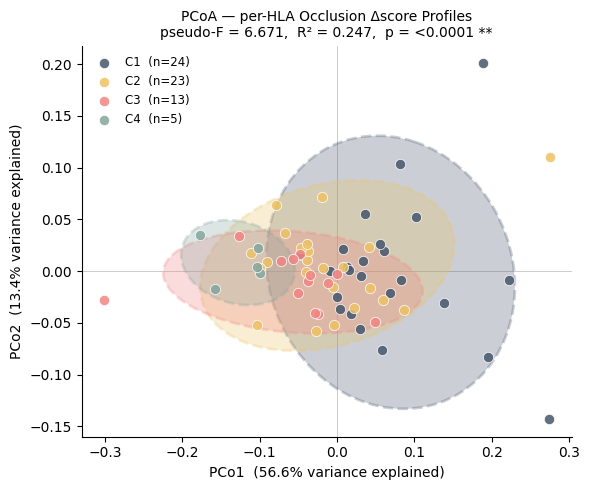

Saved fig_pcoa.pdf/.png


In [11]:
# ── PCoA of per-HLA Δscore profiles (classical PCoA via double-centering) ────
from matplotlib.patches import Ellipse as MplEllipse

def pcoa_from_distance(D, n_components=2):
    """Classical metric PCoA: double-center the squared distance matrix,
    then take eigendecomposition of the Gower centred matrix B."""
    D  = np.asarray(D); n = D.shape[0]
    H  = np.eye(n) - np.ones((n, n)) / n
    B  = -0.5 * H @ (D ** 2) @ H
    eigvals, eigvecs = np.linalg.eigh(B)
    idx     = np.argsort(eigvals)[::-1]
    eigvals = eigvals[idx]; eigvecs = eigvecs[:, idx]
    pos     = eigvals > 0
    coords  = eigvecs[:, pos][:, :n_components] * np.sqrt(eigvals[pos][:n_components])
    var_exp = eigvals[pos][:n_components] / eigvals[pos].sum()
    return coords, var_exp

def confidence_ellipse_eig(x, y, ax, n_std=2.0, **kwargs):
    if len(x) < 4:
        return
    cov = np.cov(x, y)
    if np.any(~np.isfinite(cov)):
        return
    eigvals, eigvecs = np.linalg.eigh(cov)
    order   = eigvals.argsort()[::-1]
    eigvals = eigvals[order]; eigvecs = eigvecs[:, order]
    angle   = np.degrees(np.arctan2(eigvecs[1, 0], eigvecs[0, 0]))
    width   = 2 * n_std * np.sqrt(max(eigvals[0], 0))
    height  = 2 * n_std * np.sqrt(max(eigvals[1], 0))
    ell = MplEllipse(xy=(np.mean(x), np.mean(y)),
                     width=width, height=height, angle=angle, **kwargs)
    ax.add_patch(ell)

coords, vr = pcoa_from_distance(permanova_res['distance_matrix'], n_components=2)
profile_df['PCo1'] = coords[:, 0]
profile_df['PCo2'] = coords[:, 1]

print(f'PCo1 = {vr[0]*100:.1f}%,  PCo2 = {vr[1]*100:.1f}%,  total = {sum(vr)*100:.1f}%')

fig, ax = plt.subplots(figsize=(6, 5))

for cid in sorted(profile_df['cluster'].unique()):
    sub   = profile_df[profile_df['cluster'] == cid]
    color = CLUSTER_COLORS[cid]
    cx    = sub['PCo1'].to_numpy()
    cy    = sub['PCo2'].to_numpy()

    confidence_ellipse_eig(cx, cy, ax, n_std=2.0,
                            facecolor=color, alpha=0.28,
                            edgecolor=color, linewidth=2.0,
                            linestyle='--', zorder=1)
    ax.scatter(cx, cy, color=color, s=55, alpha=0.85, zorder=3,
               edgecolors='white', linewidths=0.6,
               label=f'C{cid+1}  (n={sub["MHC"].nunique()})')

    # Centroid only if cluster contains a single HLA
    if len(sub) == 1:
        ax.scatter(cx.mean(), cy.mean(), color=color, s=160, marker='D',
                   edgecolors='white', linewidths=2.0, zorder=4)

ax.axhline(0, color='#cccccc', lw=0.7, zorder=0)
ax.axvline(0, color='#cccccc', lw=0.7, zorder=0)
ax.set_xlabel(f'PCo1  ({vr[0]*100:.1f}% variance explained)', fontsize=10)
ax.set_ylabel(f'PCo2  ({vr[1]*100:.1f}% variance explained)', fontsize=10)
ax.set_title(
    f'PCoA \u2014 per-HLA Occlusion \u0394score Profiles\n'
    f'pseudo-F = {F_obs:.3f},  R\u00b2 = {R2:.3f},  p = {p_str} {stars}',
    fontsize=10
)
ax.spines[['top', 'right']].set_visible(False)
ax.legend(fontsize=8.5, frameon=False, loc='best')
plt.tight_layout()
for ext in ('pdf', 'png'):
    fig.savefig(FIGURE_DIR / f'fig_pcoa.{ext}', dpi=150, bbox_inches='tight')
plt.show()
print('Saved fig_pcoa.pdf/.png')
